In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn

## K-Nearest Neighbors
The K-NN algorithm is arguably the simplest machine learning algorithm, building the model consist only of storing the training dataset. To make prediction for a new data point, the algorithm finds the closest data points n the training dataset- its `nearest neighbors`

##### K-Neighbors classification
the k-NN algorithm only considers exactly one nearest neighbor, which is the closest training data point to the point we want to make a prediction for. The prediction is then simply the known output for this training point.

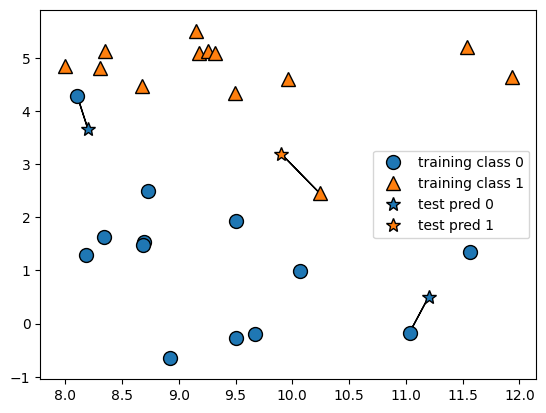

In [3]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

`Note` : Instead of considering only the closest neighbors, we can consider arbitrary number `k` of neighbors

when considering more than 1 neighbors, we use `voting` to assign label - This means that for each test point, we count how many neighbors belong to class 0 and how many neighbors belong to class 1. We then assign the class that is more frequent: in other words, the majority class among the k-nearest neighbors.


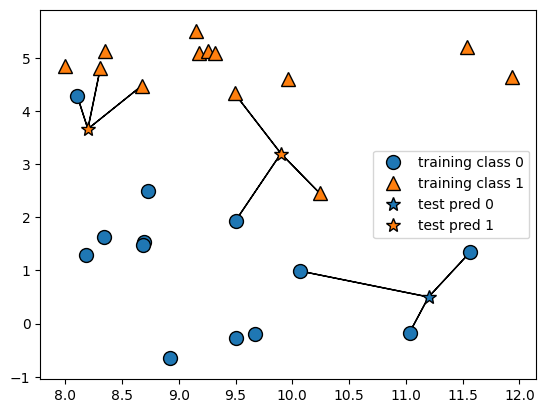

In [4]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

Basically we can consider more neighbors and based on majority we can predict the class of the data point we are predicting for 

### How to Apply KNN Algorithm using `scikit-learn`

Note - always follow - `X_train, X_test, y_train, y_test` this industry standard convention to avoid subtle bugs

In [5]:
# First we split our data into training and testing data
from sklearn.model_selection import train_test_split
X, y = mglearn.datasets.make_forge()

X_train,X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [6]:
# Now we will import and instantiate the class - this is when we can set parameters
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

In [7]:
# After instantiating the model we fit the training dtaa into the model
clf.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
# Prediction on test set 
print("Test set predictions: {}".format(clf.predict(X_test)))

Test set predictions: [1 0 1 0 1 0 0]


In [9]:
# Accuracy of our model 
print("Accuracy: {:.3f}".format(clf.score(X_test,y_test)))

Accuracy: 0.857


Analayizing KNeighborsClassifier

`Decision Boundary` - it is the line or boundary that divides between where the algorithm assigns `class 0` versus where it assigns `class 1`

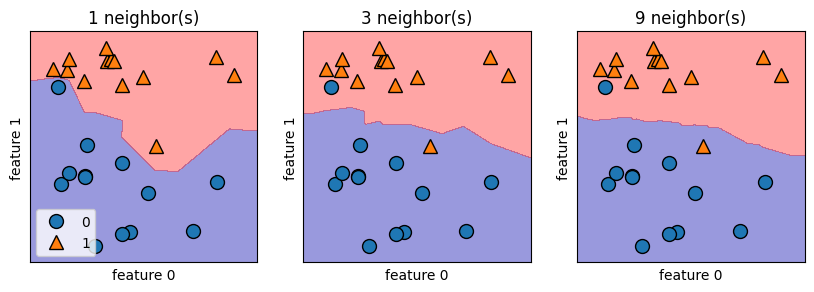

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10,3))

for n_neighbors, ax in zip([1,3,9], axes):

# the fit method returns the object self, so we can instantiate # and fit in one line 
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y) 
    mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4) 
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax) 
    ax.set_title("{} neighbor(s)".format(n_neighbors)) 
    ax.set_xlabel("feature 0") 
    ax.set_ylabel("feature 1") 
    axes[0].legend(loc=3)
axes[0].legend(loc=3)



note - using one neighbor results in decision boundary that follows the training data closely, on the other hand considering more  neighbors leads to a smoother decision boundary

Smoother boundary means model is `simple` and if the boundary is not smooth and follows the trainng data closely then the model is `complex`

- Few neighbors corresponds to high model complexity
- Less neighbors corresponds to low model complexity

## Generalization and Model Complexity

we will check this on real world data

In [11]:
# Data load
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

In [12]:
# Dividing training and testing set
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42)

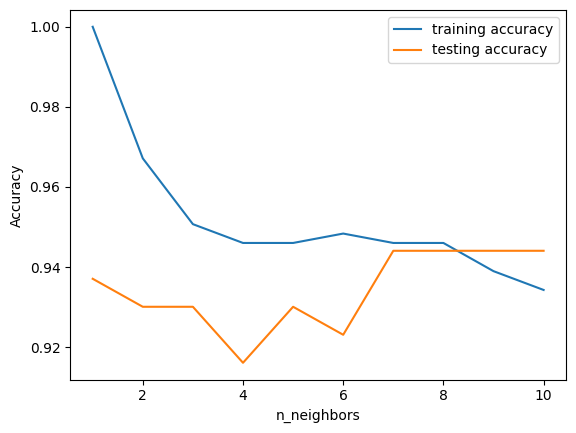

In [13]:
training_accuracy = []
test_accuracy = []

# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    # Model build
    clf = KNeighborsClassifier(n_neighbors= n_neighbors)
    clf.fit(X_train, y_train)

    #recording training set accuracy 
    training_accuracy.append(clf.score(X_train,y_train))
    # recording testing set accuracy
    test_accuracy.append(clf.score(X_test, y_test))


# Plotting the results
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings,test_accuracy, label="testing accuracy" )
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()


#### K-Neighbors Regression

There is also a regression variant of k-nearest neighbors algorithm

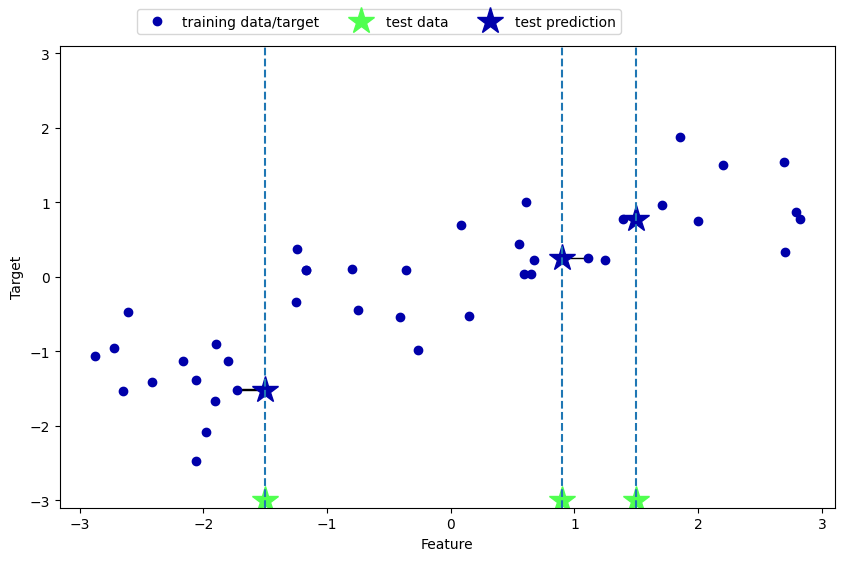

In [14]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

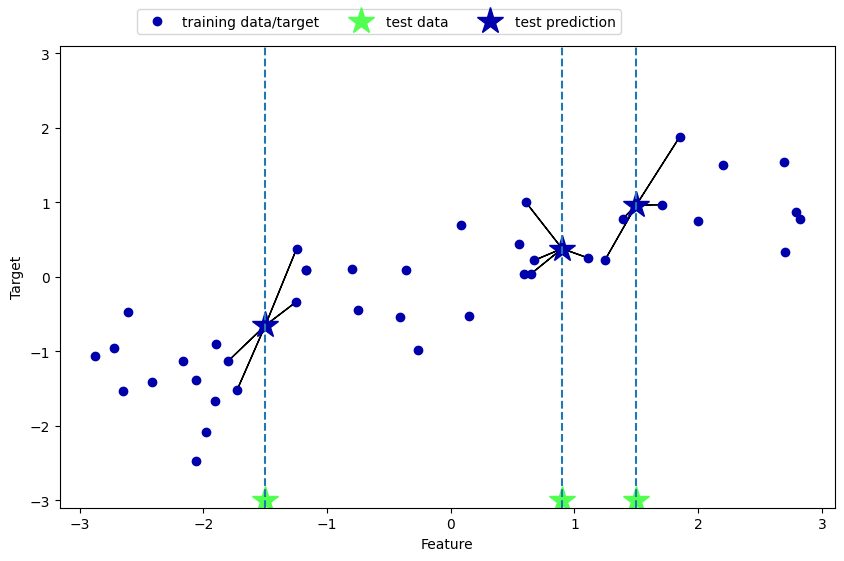

In [23]:
mglearn.plots.plot_knn_regression(n_neighbors=4)

The k-nearest neighbors algorithm for regression is implemented in the `KNeighbors regressor` class in `scikit-learn` 

In [16]:
from sklearn.neighbors import KNeighborsRegressor

X,y = mglearn.datasets.make_wave(n_samples=40)

In [17]:
# Splitting dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [18]:
# Instantiate model and set number of neighbors
reg = KNeighborsRegressor(n_neighbors=3)
# fit the data into the model
reg.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
# Predictions of knn regressor
print("Test set prediction : \n{}".format(reg.predict(X_test)))

Test set prediction : 
[ 0.18836016  0.18836016 -2.07693788 -1.75751624 -1.89415682  1.44592491
 -0.85177421 -0.35898987 -0.65851598 -0.8301424 ]


In [20]:
# Evaluate the model
print("Test set R^2 score : \n{:.2f}".format(reg.score(X_test,y_test)))

Test set R^2 score : 
0.24


### Analyzing KNeighborsRegressor

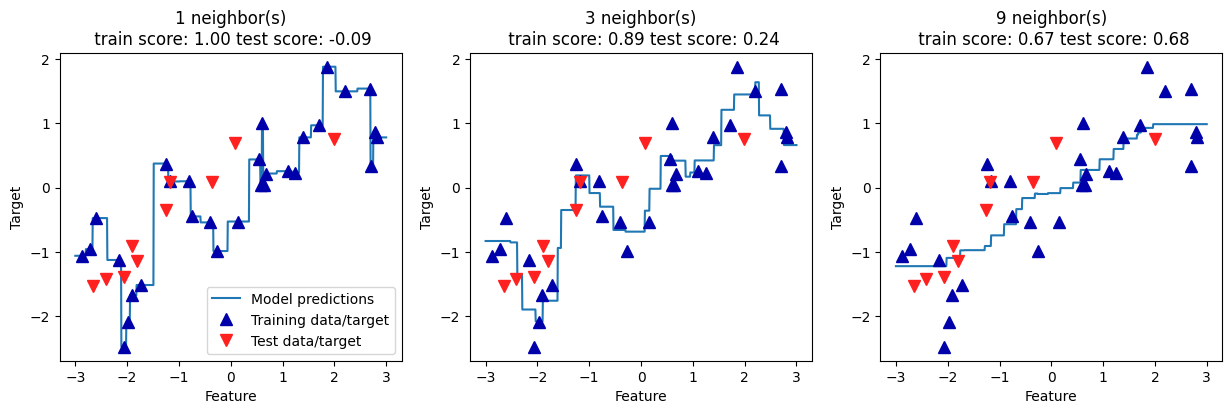

In [21]:
fig, axes =  plt.subplots(1, 3, figsize=(15,4))
# create 1,000 data points, evenly spaced between -3 and 3 
line = np.linspace(-3, 3, 1000).reshape(-1, 1) 
for n_neighbors, ax in zip([1, 3, 9], axes):
    # make predictions using 1, 3, or 9 neighbors 
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train) 
    ax.plot(line, reg.predict(line)) 
    ax.plot(X_train, y_train, '^', c=mglearn.cm2(0), markersize=8) 
    ax.plot(X_test, y_test, 'v', c=mglearn.cm2(1), markersize=8) 

    ax.set_title(
        "{} neighbor(s)\n train score: {:.2f} test score: {:.2f}".format( 
            n_neighbors, reg.score(X_train, y_train), 
            reg.score(X_test, y_test))) 
    ax.set_xlabel("Feature") 
    ax.set_ylabel("Target") 
    axes[0].legend(["Model predictions", "Training data/target",
                    "Test data/target"], loc="best")



There are 2 important parameters in KNN 
- The number of neighbors 
- and how you measure distance between data points